In [1]:
from itertools import cycle

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

_MODEL_CACHE = {}


def _load(model_name):
    from transformers import AutoTokenizer, AutoModelForCausalLM
    if model_name not in _MODEL_CACHE:
        tok = AutoTokenizer.from_pretrained(model_name)
        mdl = AutoModelForCausalLM.from_pretrained(model_name)
        _MODEL_CACHE[model_name] = (tok, mdl)
    return _MODEL_CACHE[model_name]


def _nearest_token(embedding_layer, tokenizer, vec, k=3):
    """k nearest vocabulary tokens to vec by cosine similarity."""
    W = embedding_layer.weight
    sims = torch.nn.functional.cosine_similarity(W, vec.unsqueeze(0), dim=-1)
    top = torch.topk(sims, k)
    return [(tokenizer.decode(i).strip(), s.item())
            for s, i in zip(top.values, top.indices)]


def drift_sentence_meaning_extrapolate(model_name, phrase, target_word, changed_index,
                                       alpha_min=-1.0, alpha_max=2.0,
                                       n_steps=121, thresh=0.05):
    """Sweep alpha outside [0, 1].

        e = (1 - alpha) * original + alpha * target

    alpha < 0 moves away from the target, alpha > 1 moves past it. Both leave the
    region spanned by the two real embeddings, so the resulting vector is not a
    convex combination of anything and its norm grows without bound.
    """
    if alpha_min >= alpha_max:
        raise ValueError("alpha_min must be below alpha_max")

    tokenizer, model = _load(model_name)
    embedding_layer = model.get_input_embeddings()

    def word_embedding(w):
        ids = tokenizer.encode(" " + w)
        if len(ids) != 1:
            print(f"warning: {w!r} -> {len(ids)} tokens, using first")
        return embedding_layer.weight[ids[0]]

    inputs = tokenizer(phrase, return_tensors="pt")
    attn = inputs["attention_mask"]
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    print("tokens:", list(enumerate(tokens)))

    base_embeds = embedding_layer(inputs["input_ids"]).detach()
    original_vec = base_embeds[0, changed_index, :].clone()
    target_vec = word_embedding(target_word)
    morph_word = tokenizer.decode([int(inputs["input_ids"][0][changed_index])]).strip()

    mean_norm = embedding_layer.weight.norm(dim=-1).mean().item()

    alphas = np.linspace(alpha_min, alpha_max, n_steps)
    top5_by_step, transitions, norms, prev_top = {}, [], [], None

    for i, alpha in enumerate(alphas):
        vec = (1 - alpha) * original_vec + alpha * target_vec
        norms.append(vec.norm().item())
        embeds = base_embeds.clone()
        embeds[0, changed_index, :] = vec
        with torch.no_grad():
            logits = model(inputs_embeds=embeds, attention_mask=attn).logits
        probs = torch.softmax(logits[0, -1, :], dim=-1)
        top5 = torch.topk(probs, 5)
        top5_by_step[i] = top5
        pred = tokenizer.decode(top5.indices[0]).strip()
        if prev_top is not None and pred != prev_top:
            transitions.append((float(alpha), prev_top, pred))
        prev_top = pred

    norms = np.array(norms)

    print(f"\nmorphing {morph_word!r} -> {target_word!r} over alpha in [{alpha_min}, {alpha_max}]")
    print(f"  alpha={alphas[0]:+.2f}   {tokenizer.decode(top5_by_step[0].indices[0]).strip()!r}")
    for a, frm, to in transitions:
        flag = "" if 0 <= a <= 1 else "   (extrapolated)"
        print(f"  alpha={a:+.2f}   {frm!r} -> {to!r}{flag}")
    print(f"  alpha={alphas[-1]:+.2f}   {tokenizer.decode(top5_by_step[n_steps - 1].indices[0]).strip()!r}")
    inside = sum(1 for a, *_ in transitions if 0 <= a <= 1)
    print(f"  {len(transitions)} change(s): {inside} inside [0,1], {len(transitions) - inside} outside")

    print(f"\nmean vocab embedding norm: {mean_norm:.2f}")
    for a in (alpha_min, 0.0, 1.0, alpha_max):
        vec = (1 - a) * original_vec + a * target_vec
        near = _nearest_token(embedding_layer, tokenizer, vec, k=3)
        near_str = ", ".join(f"{w!r} {s:.2f}" for w, s in near)
        print(f"  alpha={a:+.2f}  norm={vec.norm().item():6.2f} "
              f"({vec.norm().item() / mean_norm:4.1f}x mean)  nearest: {near_str}")

    steps = sorted(top5_by_step)
    per_step = {i: {idx.item(): p.item()
                    for p, idx in zip(top5_by_step[i].values, top5_by_step[i].indices)}
                for i in steps}
    all_ids = {t for d in per_step.values() for t in d}

    fallback = cycle(plt.get_cmap("tab20").colors)
    color_by_id = {}
    for t in sorted(all_ids):
        w = tokenizer.decode(t).strip().lower()
        color_by_id[t] = ("dimgray" if w == "black"
                          else w if w in mcolors.CSS4_COLORS else next(fallback))

    def mark_regions(ax):
        if alpha_min < 0:
            ax.axvspan(alpha_min, 0, color="lightgray", alpha=0.35, zorder=0)
        if alpha_max > 1:
            ax.axvspan(1, alpha_max, color="lightgray", alpha=0.35, zorder=0)
        for a in (0.0, 1.0):
            if alpha_min <= a <= alpha_max:
                ax.axvline(a, color="black", linewidth=1)
        for a, *_ in transitions:
            ax.axvline(a, color="red", linestyle="--", linewidth=1)

    fig, ax = plt.subplots(figsize=(11, 6))
    for t in all_ids:
        probs = [per_step[i].get(t, float("nan")) for i in steps]
        ax.plot(alphas, probs, marker=".", color=color_by_id[t],
                label=tokenizer.decode(t).strip(), zorder=2)
    mark_regions(ax)
    ax.set_xlabel(f"alpha (0 = {morph_word!r}, 1 = {target_word!r}; shaded = extrapolation)")
    ax.set_ylabel("probability")
    ax.set_xlim(alpha_min, alpha_max)
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    band = {t: np.array([per_step[i].get(t, 0.0) for i in steps]) for t in all_ids}
    keep = sorted((t for t in all_ids if band[t].max() >= thresh),
                  key=lambda t: int(np.argmax(band[t])))
    if not keep:
        keep = sorted(all_ids, key=lambda t: -band[t].max())[:5]
        keep = sorted(keep, key=lambda t: int(np.argmax(band[t])))
    M = np.vstack([band[t] for t in keep])
    other = 1 - M.sum(axis=0)

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.stackplot(alphas, *M, other,
                 labels=[tokenizer.decode(t).strip().lower() for t in keep] + ["other"],
                 colors=[color_by_id[t] for t in keep] + ["lightgray"])
    for a in (0.0, 1.0):
        if alpha_min <= a <= alpha_max:
            ax.axvline(a, color="black", linewidth=1)
    for a, *_ in transitions:
        ax.axvline(a, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel(f"alpha (0 = {morph_word!r}, 1 = {target_word!r})")
    ax.set_ylabel("probability")
    ax.set_xlim(alpha_min, alpha_max); ax.set_ylim(0, 1)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
    plt.tight_layout(); plt.show()



    return top5_by_step, transitions, norms

/Users/dariushghassemieh/llms/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16795.37it/s]


tokens: [(0, 'I'), (1, 'Ġlove'), (2, 'Ġschool'), (3, 'Ġbecause'), (4, 'Ġit'), (5, "'s"), (6, 'Ġvery'), (7, ','), (8, 'Ġvery')]

morphing 'love' -> 'hate' over alpha in [-4.5, 4.5]
  alpha=-4.50   'good'
  alpha=-3.30   'good' -> 'hard'   (extrapolated)
  alpha=-1.50   'hard' -> 'fun'   (extrapolated)
  alpha=+0.60   'fun' -> 'hard'
  alpha=+3.07   'hard' -> ','   (extrapolated)
  alpha=+4.50   ','
  4 change(s): 1 inside [0,1], 3 outside

mean vocab embedding norm: 3.96
  alpha=-4.50  norm= 15.65 ( 4.0x mean)  nearest: 'love' 0.58, 'LOVE' 0.34, 'loves' 0.34
  alpha=+0.00  norm=  3.25 ( 0.8x mean)  nearest: 'love' 1.00, 'LOVE' 0.74, 'Love' 0.72
  alpha=+1.00  norm=  3.43 ( 0.9x mean)  nearest: 'hate' 1.00, 'Hate' 0.77, 'hate' 0.74
  alpha=+4.50  norm= 12.99 ( 3.3x mean)  nearest: 'hate' 0.69, 'Hate' 0.55, 'hate' 0.51


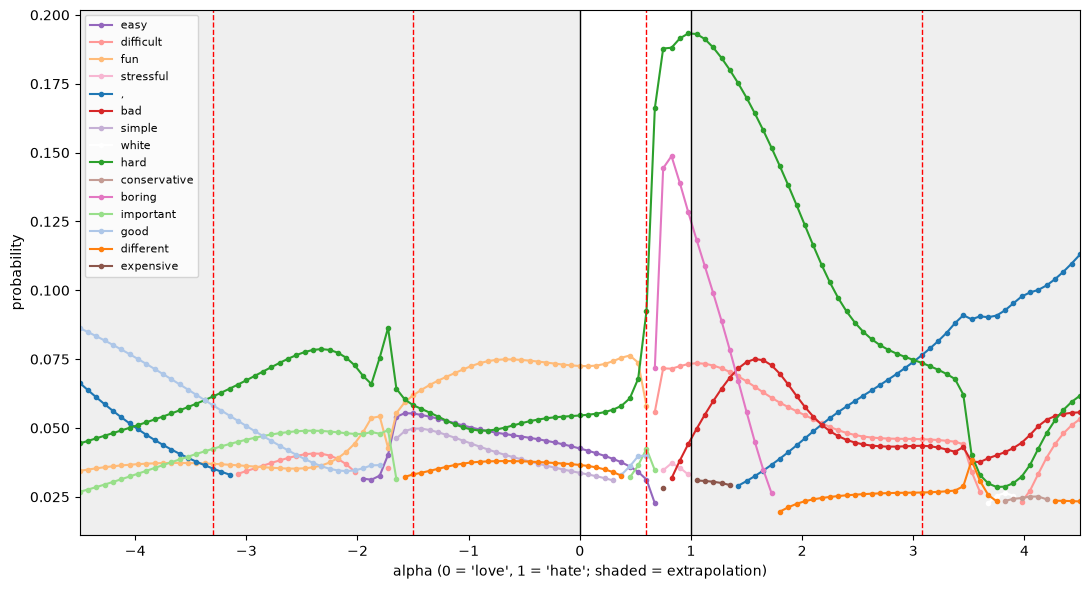

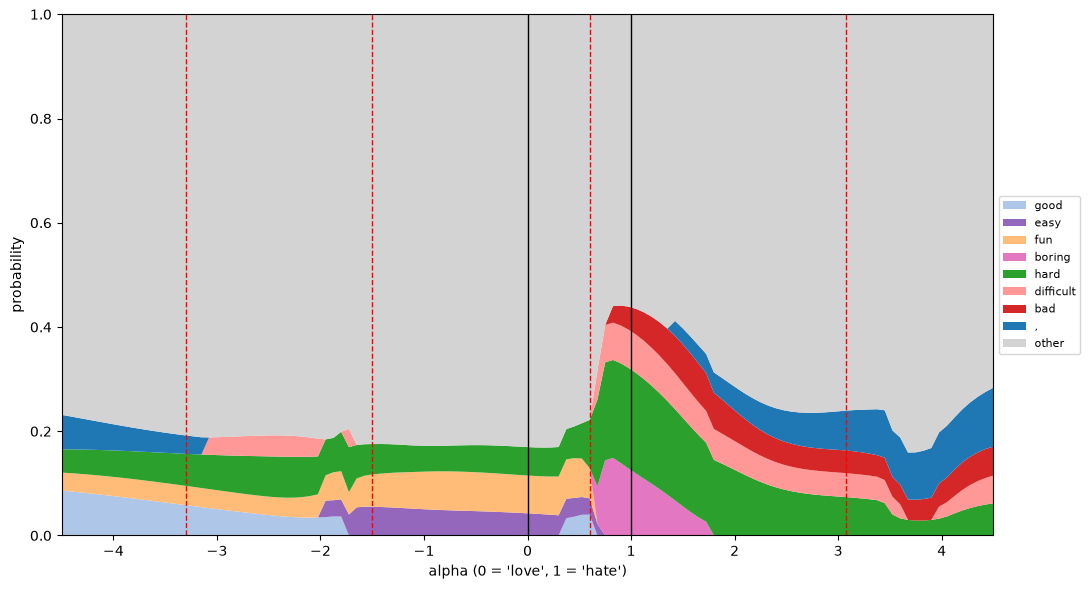

({0: torch.return_types.topk(
  values=tensor([0.0863, 0.0664, 0.0444, 0.0344, 0.0268]),
  indices=tensor([ 922,   11, 1327, 1257, 1593])),
  1: torch.return_types.topk(
  values=tensor([0.0848, 0.0637, 0.0453, 0.0349, 0.0277]),
  indices=tensor([ 922,   11, 1327, 1257, 1593])),
  2: torch.return_types.topk(
  values=tensor([0.0833, 0.0611, 0.0462, 0.0354, 0.0285]),
  indices=tensor([ 922,   11, 1327, 1257, 1593])),
  3: torch.return_types.topk(
  values=tensor([0.0818, 0.0586, 0.0472, 0.0358, 0.0295]),
  indices=tensor([ 922,   11, 1327, 1257, 1593])),
  4: torch.return_types.topk(
  values=tensor([0.0802, 0.0562, 0.0481, 0.0361, 0.0304]),
  indices=tensor([ 922,   11, 1327, 1257, 1593])),
  5: torch.return_types.topk(
  values=tensor([0.0785, 0.0539, 0.0491, 0.0364, 0.0314]),
  indices=tensor([ 922,   11, 1327, 1257, 1593])),
  6: torch.return_types.topk(
  values=tensor([0.0768, 0.0517, 0.0501, 0.0367, 0.0324]),
  indices=tensor([ 922,   11, 1327, 1257, 1593])),
  7: torch.return_ty

In [2]:
drift_sentence_meaning_extrapolate(
    "gpt2", "I love school because it's very, very", "hate",
    changed_index=1, alpha_min=-4.5, alpha_max=4.5,
)